In [6]:
import pandas as pd
import torch

df = pd.read_parquet("/Users/tomstent/Documents/applied_mathematics_msc/probabilistic_neural_operators/datasets/stochastic/NS%2B_u0_xi_trc128_1200_seed42.parquet")
print(df.columns) 
print(df.shape)

Index(['X', 'Y', 'T', 'W', 'sol'], dtype='str')
(31027200, 5)


In [9]:
n_samples = int(31027200 / (101 * 16 * 16))
n_t = 101
n_x = 16
n_y = 16

sol = torch.tensor(df['sol'].values, dtype=torch.float32).reshape(n_samples, n_t, n_x, n_y)
W   = torch.tensor(df['W'].values, dtype=torch.float32).reshape(n_samples, n_t, n_x, n_y)

In [11]:
print(sol.shape)
print(W.shape)

torch.Size([1200, 101, 16, 16])
torch.Size([1200, 101, 16, 16])


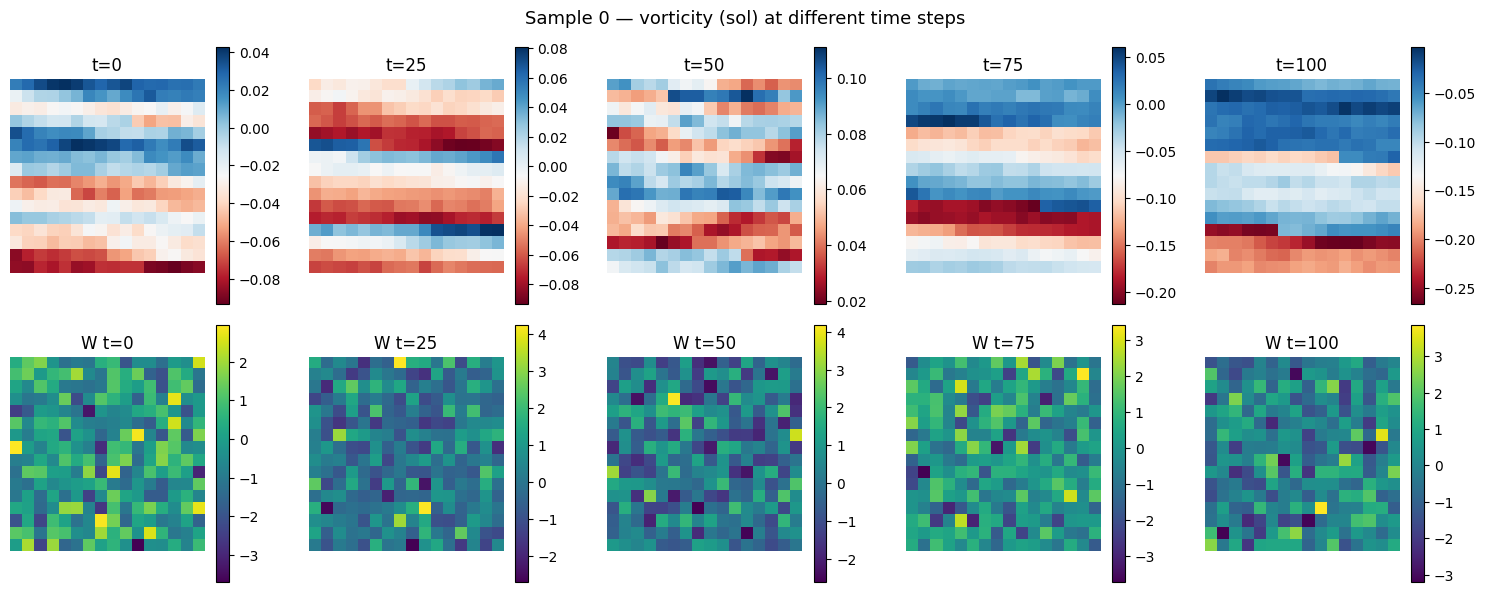

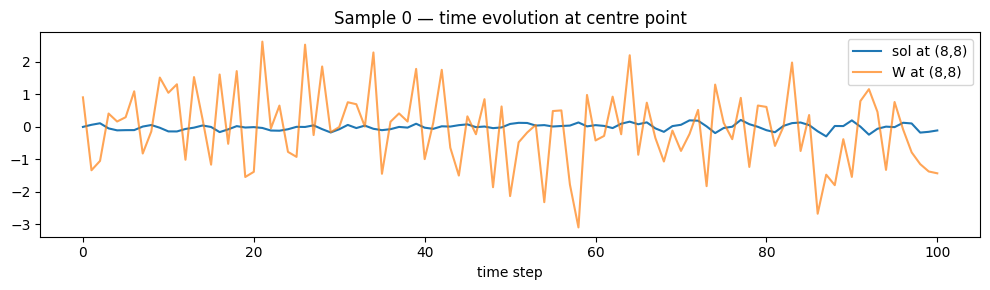

In [12]:
import matplotlib.pyplot as plt
import numpy as np

n_t = 101
n_x = 16
n_y = 16
n_samples = int(len(df) / (n_t * n_x * n_y))

sol = torch.tensor(df['sol'].values, dtype=torch.float32).reshape(n_samples, n_t, n_x, n_y)
W   = torch.tensor(df['W'].values, dtype=torch.float32).reshape(n_samples, n_t, n_x, n_y)

# Pick one sample to visualise
s = 0

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f'Sample {s} — vorticity (sol) at different time steps', fontsize=13)

timesteps = np.linspace(0, n_t-1, 5, dtype=int)
for i, t in enumerate(timesteps):
    im = axes[0, i].imshow(sol[s, t], cmap='RdBu', origin='lower')
    axes[0, i].set_title(f't={t}')
    axes[0, i].axis('off')
    plt.colorbar(im, ax=axes[0, i])

    im = axes[1, i].imshow(W[s, t], cmap='viridis', origin='lower')
    axes[1, i].set_title(f'W t={t}')
    axes[1, i].axis('off')
    plt.colorbar(im, ax=axes[1, i])

axes[0, 0].set_ylabel('sol', fontsize=10)
axes[1, 0].set_ylabel('W', fontsize=10)

plt.tight_layout()
plt.show()

# Also plot time evolution at a single spatial point
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(sol[s, :, 8, 8].numpy(), label='sol at (8,8)')
ax.plot(W[s, :, 8, 8].numpy(), label='W at (8,8)', alpha=0.7)
ax.set_xlabel('time step')
ax.legend()
ax.set_title(f'Sample {s} — time evolution at centre point')
plt.tight_layout()
plt.show()